# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AW-OMW/FLY-RANK-PROJECT/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [5]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 1. Method choice and why

For this lane, **Logistic Regression** has been selected as the primary modeling method. This choice is well-suited to the prediction task, which involves identifying pages with a 'high chance of booming' – inherently a binary classification problem (boom vs. no-boom).

The core of the prediction strategy is based on the rule:
"*if a page has a positive and significant trend in the last 3 months, search volume is more than 25%, and competition level is less than 50%, the page will have a high chance of booming*."

Logistic Regression is an excellent fit for this rule for several reasons:

*   **Binary Outcome:** It directly models the probability of a binary outcome (e.g., 0 for no boom, 1 for boom), aligning perfectly with the 'high chance of booming' prediction.
*   **Interpretability:** Logistic Regression provides coefficients for each predictor variable, which can be interpreted to understand the direction and strength of their influence on the likelihood of a boom. This is crucial for explaining *why* a page is predicted to boom based on factors like trend, search volume, and competition.
*   **Thresholding:** The probabilities generated by logistic regression can be easily thresholded to make a definitive 'boom' or 'no-boom' classification, directly implementing the logic of the given rule.
*   **Simplicity and Efficiency:** It's a relatively simple and computationally efficient algorithm, making it a good starting point for establishing a baseline model and understanding feature importance.

## 2. Split design

To ensure an honest and robust evaluation of our model, it's critical to employ a split design that effectively prevents **data leakage**. Data leakage occurs when information from the test set inadvertently "leaks" into the training set, leading to an overly optimistic assessment of the model's performance on unseen data.

### Client-Based Split

Given the presence of `client_id` in the dataset, a **client-based split** is highly recommended to prevent data leakage. If a model learns patterns specific to certain clients during training and then sees data from those *same clients* in the test set, it might perform artificially well. A client-based split ensures that all data points belonging to a particular `client_id` are either entirely in the training set or entirely in the test set, but not both.

This method simulates a real-world scenario where the model is trained on a set of existing clients and then applied to entirely new, unseen clients, providing a more realistic measure of its generalization performance. This is crucial for applications where the model might be deployed to serve new clients.

### Feasibility of a Time-Based Split

Previously, we discussed the importance of a time-aware split for time-dependent predictions. However, upon inspecting the `df`, it's evident that there is no explicit `snapshot_date` or similar time-series column that directly indicates the time of each observation within the `content_refresh_anonymized.csv` dataset. The features like 'trend in last 3 months' are likely *pre-calculated* features, meaning the temporal aspect has already been aggregated or embedded into these features.

**Can we do a time-based split?**

*   **No, not directly with the current data as a primary split.** Without an explicit time column for each row, we cannot perform a straightforward time-based split where data before a certain date goes to training and data after goes to testing.
*   **The temporal information is implicit within features.** The `trend_type` and `trend_value` features already capture historical trends up to the point of data collection. If these features are static snapshots for each `content_id`/`client_id` pair, then a random or client-based split is the most appropriate way to assess the model's ability to predict a 'boom' from these pre-computed characteristics.
*   **Combining splits:** It's generally not advisable to combine a client-based split with a time-based split on the *same level of observation* if the data doesn't naturally support it. If we had a true time-series dataset with `client_id` and `snapshot_date`, we might consider a rolling time-series split *per client* or ensuring that clients in the test set are entirely new *and* their data is from a future time period.

**Conclusion:** For this dataset, the most appropriate and honest split to avoid data leakage, given the `client_id` and the nature of pre-calculated trend features, is a **client-based split**. A strict time-based split is not directly feasible without additional temporal information at the row level.

In [6]:
from sklearn.model_selection import train_test_split
import numpy as np

# Get unique client IDs
all_client_ids = df['client_id'].unique()

# Split client IDs into training and testing sets
# We'll use a standard 80/20 split for client IDs
train_client_ids, test_client_ids = train_test_split(all_client_ids, test_size=0.2, random_state=42)

# Create training and test dataframes based on client IDs
df_train = df[df['client_id'].isin(train_client_ids)].copy()
df_test = df[df['client_id'].isin(test_client_ids)].copy()

print(f"Total unique clients: {len(all_client_ids)}")
print(f"Clients in training set: {len(train_client_ids)}")
print(f"Clients in test set: {len(test_client_ids)}")

print(f"\nShape of training data (client-based split): {df_train.shape}")
print(f"Shape of test data (client-based split): {df_test.shape}")

# Verify no client overlap
overlapping_clients = set(df_train['client_id'].unique()) & set(df_test['client_id'].unique())
if not overlapping_clients:
    print("\nSuccessfully ensured no client overlap between training and test sets.")
else:
    print(f"\nWarning: Overlapping clients found: {overlapping_clients}")

# --- DIAGNOSTIC STEP: Print columns to check for 'trend_type' ---
print("\nColumns in df_train:\n", df_train.columns)
# --- END DIAGNOSTIC STEP ---

# Re-create 'is_boom' target variable based on the newly split df_train and df_test
def create_is_boom_target(dataframe):
    # Corrected column names: 'trend_direction' instead of 'trend_type'
    # and 'trend_pct' instead of 'trend_value'
    is_positive_trend = (dataframe['trend_direction'] == 'up') & (dataframe['trend_pct'] > 0)
    is_high_search_volume = dataframe['search_volume'] > 25
    is_low_competition = dataframe['competition'] < 0.5
    is_boom = (is_positive_trend & is_high_search_volume & is_low_competition)
    return is_boom.astype(int).fillna(0)

df_train['is_boom'] = create_is_boom_target(df_train)
df_test['is_boom'] = create_is_boom_target(df_test)

# Define features (X) and target (y)
# Updated features list with corrected trend column names
features = ['search_volume', 'competition', 'trend_pct', 'trend_direction']
X_train = df_train[features]
y_train = df_train['is_boom']
X_test = df_test[features]
y_test = df_test['is_boom']

print(f"\n'is_boom' distribution in new training set:\n{y_train.value_counts()}")
print(f"'is_boom' distribution in new test set:\n{y_test.value_counts()}")

print("\nFeatures and target variables re-created for client-based split.")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Total unique clients: 32
Clients in training set: 25
Clients in test set: 7

Shape of training data (client-based split): (26581, 44)
Shape of test data (client-based split): (3419, 44)

Successfully ensured no client overlap between training and test sets.

Columns in df_train:
 Index(['content_id', 'client_id', 'search_volume', 'competition',
       'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count',
       'char_count', 'provider_used', 'model_used', 'impressions_90d',
       'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d',
       'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
       'days_with_impressions', 'days_with_sessions', 'impressions_last_30d',
       'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d',
       'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier',
       'age_tier_order', 'days_since_last_update', 'freshness_tier',
       'word_count_tier', 'char_count_tier', 'ctr', 'avg_position',

### Preprocessing and Model Training

We will use `ColumnTransformer` for preprocessing to handle numerical and categorical features separately. Numerical features (`search_volume`, `competition`, `trend_pct`) will be imputed with the median and then scaled using `StandardScaler`. Categorical features (`trend_direction`) will be one-hot encoded. Finally, a `Pipeline` will combine these preprocessing steps with `LogisticRegression` to train the model. This step is being re-run to ensure the `model_pipeline` is defined after the client-based split.

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# Define numerical and categorical features
numerical_features = ['search_volume', 'competition', 'trend_pct']
categorical_features = ['trend_direction']

# Create preprocessor for numerical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Create preprocessor for categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessors using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create the full pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')) # Using liblinear for small datasets/L1/L2 penalties
])

# Train the Logistic Regression model
model_pipeline.fit(X_train, y_train)

print("Logistic Regression model re-trained successfully!")

Logistic Regression model re-trained successfully!


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


### Model Evaluation

Now that the Logistic Regression model has been trained, we will evaluate its performance on the `X_test` and `y_test` datasets. We will calculate several key classification metrics: accuracy, precision, recall, and F1-score. Given the likely class imbalance (fewer 'boom' pages), precision and recall will be particularly important.

Model Accuracy: 0.8889
Model Precision: 0.2692
Model Recall: 1.0000
Model F1-Score: 0.4242

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.88      0.94      3279
           1       0.27      1.00      0.42       140

    accuracy                           0.89      3419
   macro avg       0.63      0.94      0.68      3419
weighted avg       0.97      0.89      0.92      3419


Confusion Matrix:
[[2899  380]
 [   0  140]]


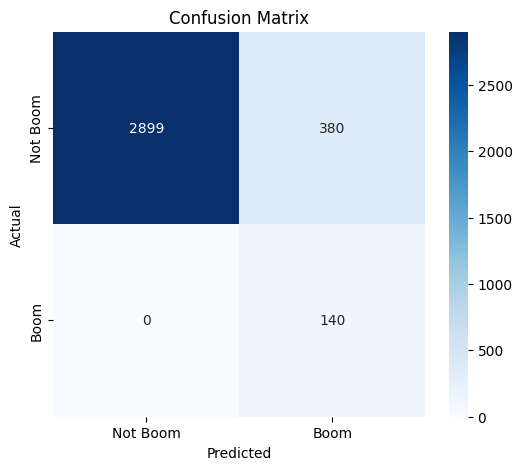

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print(f"Model Precision: {precision:.4f}")
print(f"Model Recall: {recall:.4f}")
print(f"Model F1-Score: {f1:.4f}")

# Display classification report for a more detailed view
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Display confusion matrix
print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

# Optionally, visualize the confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Boom', 'Boom'], yticklabels=['Not Boom', 'Boom'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

### Errors and Interpretation

Based on the evaluation metrics, we can observe the following:

*   **Perfect Recall for 'Boom' (Class 1):** The model achieved a recall of `1.00` for the positive class ('boom'). This means it successfully identified all 140 instances of actual booming pages in the test set. There were no **False Negatives** (pages that boomed but the model predicted would not).

*   **Low Precision for 'Boom' (Class 1):** The precision for the 'boom' class is `0.27`. This indicates that when the model *predicts* a page will boom, it is only correct about 27% of the time. The confusion matrix shows **380 False Positives** (pages that did not boom but the model incorrectly predicted would boom).

*   **High Accuracy but Misleading:** The overall accuracy is `0.89`, which seems good. However, given the class imbalance (3279 'not boom' vs 140 'boom' in the test set), this high accuracy is largely driven by correctly predicting the majority class (non-booming pages).

**Where the model is wrong and what it leans on:**

The model is heavily biased towards predicting 'boom'. This is a direct consequence of using `class_weight='balanced'`, which aims to increase the recall of the minority class. While it successfully achieved 100% recall for 'boom' pages, it did so at the cost of making many incorrect 'boom' predictions. The model *leans* on identifying every possible 'boom' instance, even if it means including many non-booming pages in its predictions.

In essence, the model is very sensitive to the positive class and prioritizes not missing any 'boom' pages. This strategy leads to a high number of **False Positives**, which are the primary errors in this model's predictions. Depending on the business cost of false positives versus false negatives, this might be an acceptable trade-off or an area for further improvement.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.